# Stock Market Prediction Using Transformers with Prompt engineering


Time series data comprises a sequence of data points arranged in chronological order. Given its ubiquity, mastering the manipulation of time series data is crucial for data analysts and scientists.

Within this notebook, we'll investigate data sourced from the stock market, with a focus on several prominent technology stocks Utilizing yfinance, we'll gather stock information and leverage Matplotlib to visualize various facets of the data. Additionally, we'll explore various methodologies for assessing a stock's risk by analyzing its historical performance.

We used transformers library for leveraging GPT2 model, additionally we used yfinance to access Apple stock market quotes.

In [1]:
!pip install yfinance
!pip install mplfinance
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 26.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 3.7 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.1-cp310-cp310-linux_x86_64.whl size=291653 sha256=5760f944b4c133f869eb460b5272a293bc9de8e18bd3c47b18bc62a6bfbc905e
  Stored in directory: /root/.cache/pip/wheels/d7/35/5c/1374782be033462df5f40174d8d879519d64ed8c25a1977554
Successfully built peewee
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.8 MB/s eta 0:00:00a 0:00:01


In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math
import pandas as pd
from sklearn.metrics import mean_squared_error
import mplfinance as mpf

## Specs
We will work on
**daily** time frame of the **Apple** stocks using previous year's data. we will use more data when dealing with exact macth predictions.

In [3]:
ticker = "AAPL" # The stock

data = yf.download(ticker, period='1y') # Previous year

data.head(5)

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-03-02,144.380005,146.710007,143.899994,145.910004,145.135330,52238100
2023-03-03,148.039993,151.110001,147.330002,151.029999,150.228134,70732300
2023-03-06,153.789993,156.300003,153.460007,153.830002,153.013275,87558000
2023-03-07,153.699997,154.029999,151.130005,151.600006,150.795105,56182000
2023-03-08,152.809998,153.470001,151.830002,152.869995,152.058365,47204800


## Statistics
Let's investigate the descriptive statistics of the data using pandas mehods.

In [4]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,252.000000,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,179.257818,180.747818,177.938849,179.465635,178.941321,5.722326e+07
std,11.752039,11.546067,11.677020,11.563614,11.703760,1.671381e+07
min,144.380005,146.710007,143.899994,145.910004,145.135330,2.404830e+07
25%,172.462498,173.982494,171.407497,172.962505,172.401772,4.678918e+07
50%,180.379997,182.079994,178.440002,180.640007,180.048981,5.322830e+07
75%,189.277496,189.990005,187.652500,189.317501,188.879906,6.324625e+07
max,198.020004,199.619995,197.000000,198.110001,197.857529,1.366826e+08


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2023-03-02 to 2024-03-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       252 non-null    float64
 1   High       252 non-null    float64
 2   Low        252 non-null    float64
 3   Close      252 non-null    float64
 4   Adj Close  252 non-null    float64
 5   Volume     252 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.8 KB


## Splitiing
We split the data for training and prediction based on the fact that test dataset is our actual prices compared to generated ones.

In [6]:
testRatio = 0.2

testCount = math.floor(data.shape[0] * testRatio)
trainDf = data.iloc[0:data.shape[0] - testCount]
testDf = data.iloc[data.shape[0] - testCount - 1:]

In [7]:
trainDf.shape

(202, 6)

## Visualization
Lets see how we can plot different aspects of our dataframe.

In [8]:
prices = data["Close"].tolist()

trainLows = trainDf["Low"].tolist()
trainHighs = trainDf["High"].tolist()
trainOpens = trainDf["Open"].tolist()
trainCloses = trainDf["Close"].tolist()
trainVol = trainDf["Volume"].tolist()

testLows = testDf["Low"].tolist()
testHighs = testDf["High"].tolist()
testOpens = testDf["Open"].tolist()
testCloses = testDf["Close"].tolist()
testVol = testDf["Volume"].tolist()

trainCombined = [trainOpens, trainCloses]
testCombined = [testOpens, testCloses]

**Plottting different prices in our dataframe against time.**

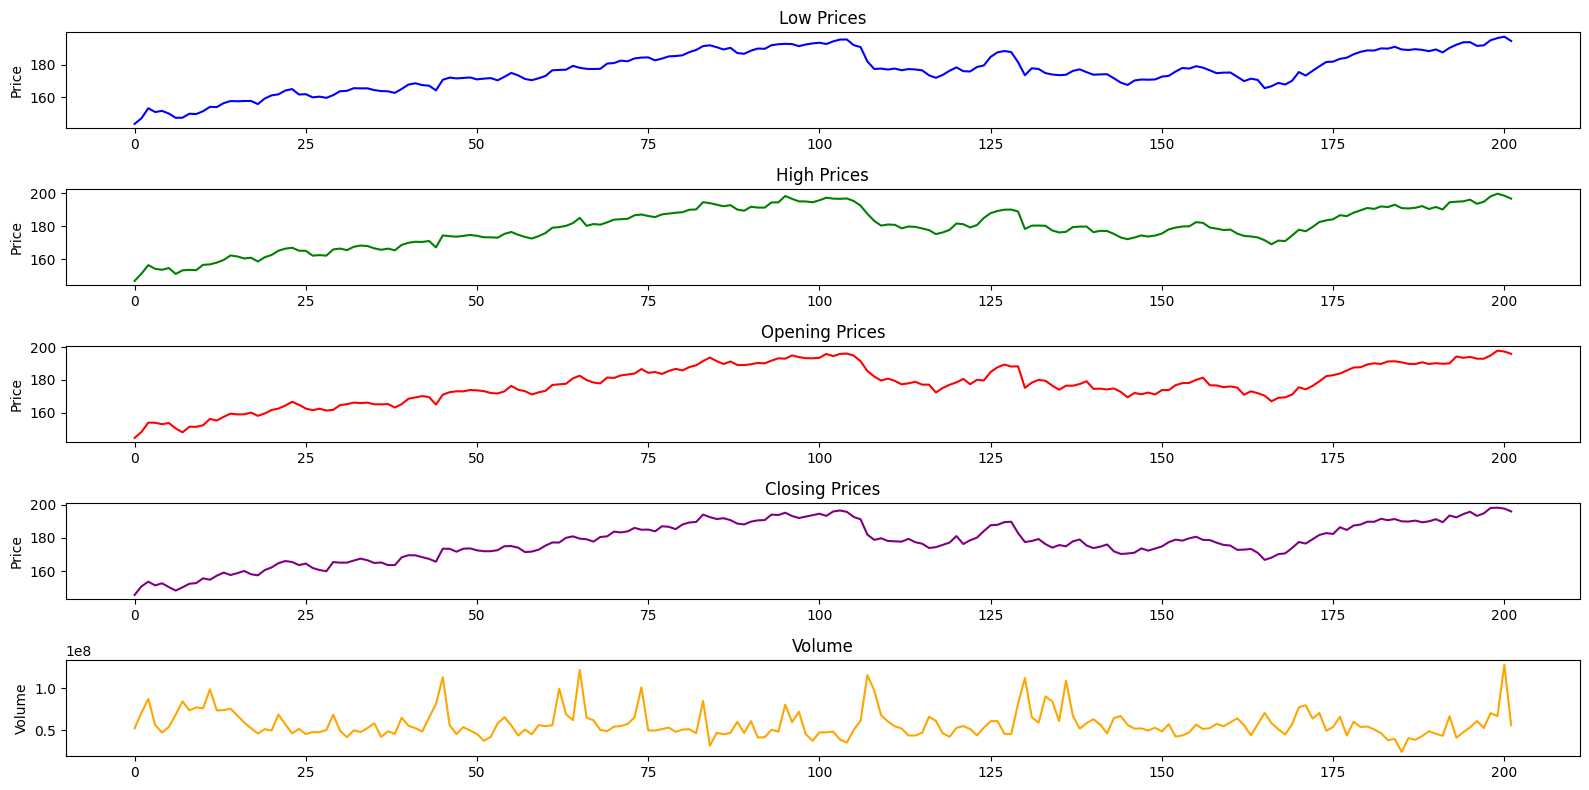

In [9]:
fig, axs = plt.subplots(5, 1, figsize=(16, 8))

axs[0].plot(trainLows, color='blue')
axs[0].set_title('Low Prices')
axs[0].set_ylabel('Price')

axs[1].plot(trainHighs, color='green')
axs[1].set_title('High Prices')
axs[1].set_ylabel('Price')

axs[2].plot(trainOpens, color='red')
axs[2].set_title('Opening Prices')
axs[2].set_ylabel('Price')

axs[3].plot(trainCloses, color='purple')
axs[3].set_title('Closing Prices')
axs[3].set_ylabel('Price')

axs[4].plot(trainVol, color='orange')
axs[4].set_title('Volume')
axs[4].set_ylabel('Volume')

plt.tight_layout()
plt.show()

**Actual candle sticks.**

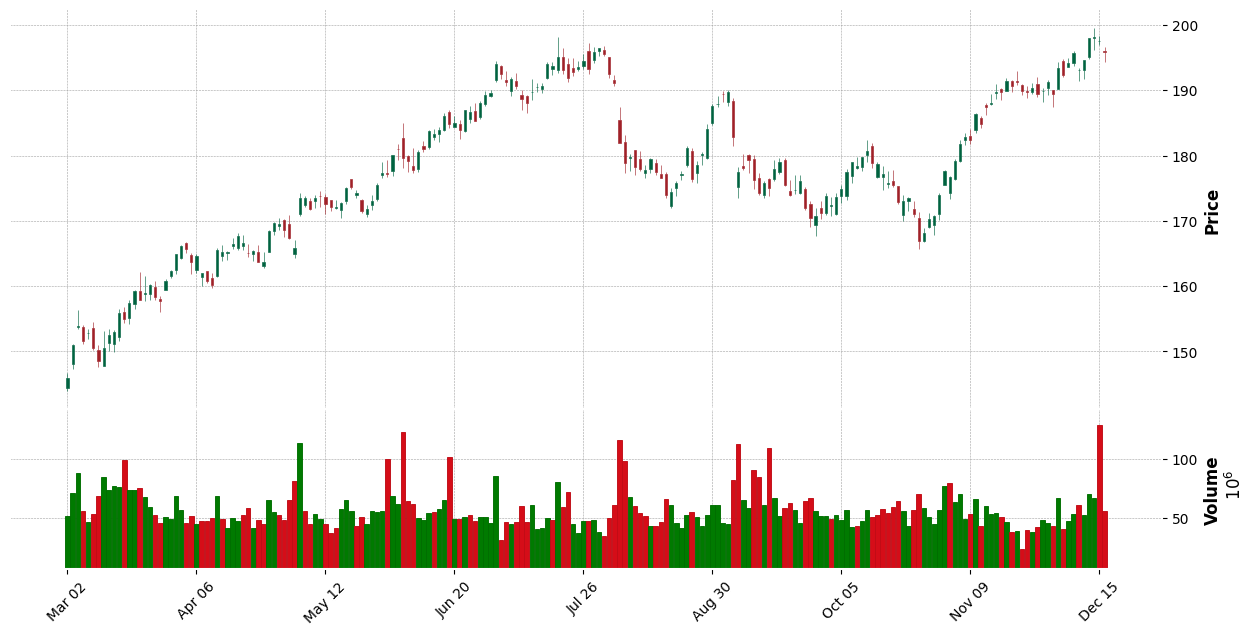

In [10]:
ohlc_data = trainDf[['Open', 'High', 'Low', 'Close', 'Volume']]

mpf.plot(ohlc_data, type='candle', style='charles',
         ylabel='Price', ylabel_lower='Volume',
         volume=True, figsize=(16, 8))

**Plotting all the prices in one axes**

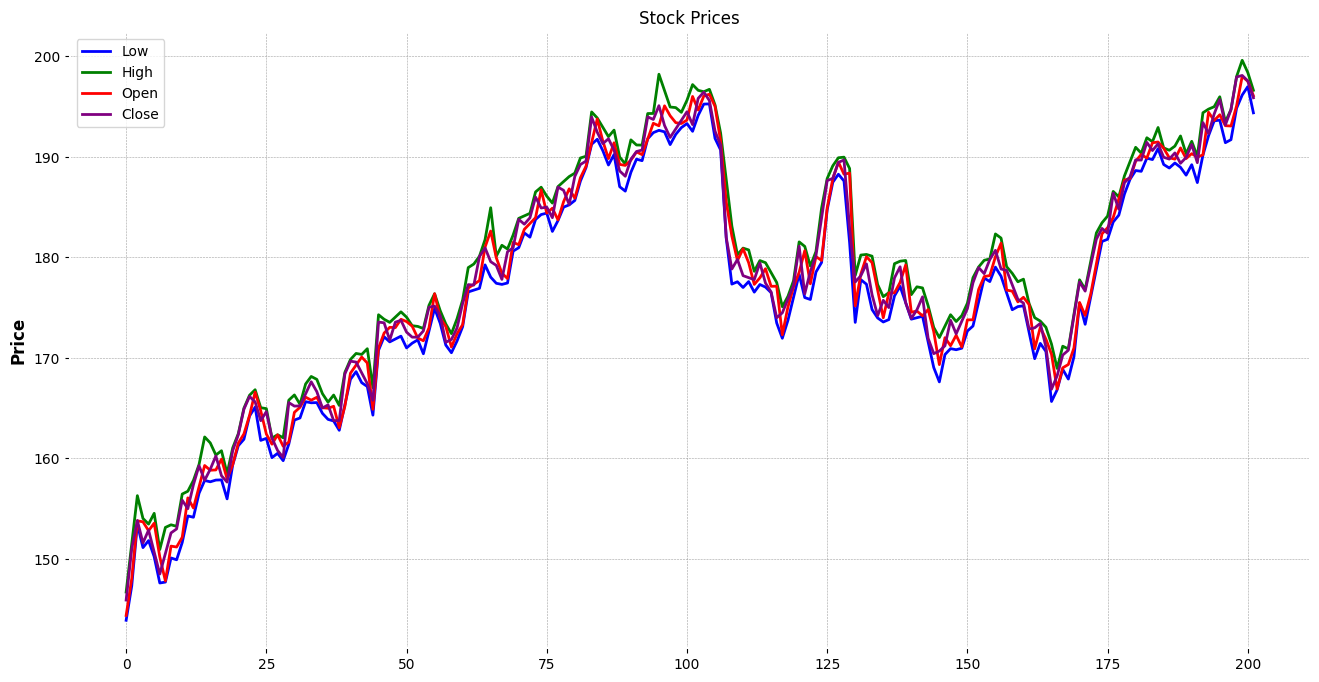

In [11]:
# Plotting
plt.figure(figsize=(16, 8))

plt.plot(trainLows, label='Low', color='blue')
plt.plot(trainHighs, label='High', color='green')
plt.plot(trainOpens, label='Open', color='red')
plt.plot(trainCloses, label='Close', color='purple')

plt.ylabel('Price')
plt.title('Stock Prices')
plt.legend()

plt.show()

**Our split in plot.**

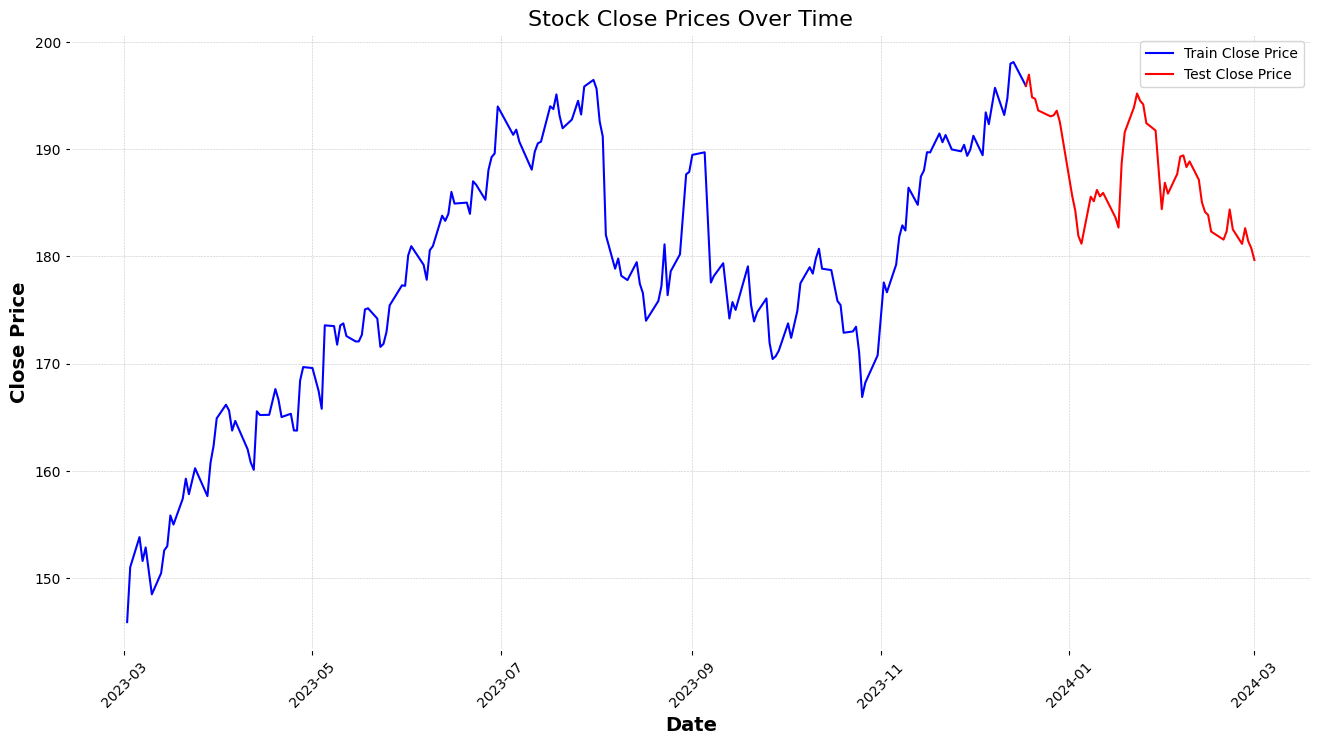

In [12]:
plt.figure(figsize=(16, 8))

plt.plot(trainDf.index, trainDf["Close"], color='blue', linewidth=1.5, label='Train Close Price')

plt.plot(testDf.index, testDf["Close"], color='red', linewidth=1.5, label='Test Close Price')

plt.title('Stock Close Prices Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price', fontsize=14)

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.show()

**Let's plot some moving averegaes**

/tmp/ipykernel_34/3665310320.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainDf[column_name] = trainDf['Close'].rolling(ma).mean()
/tmp/ipykernel_34/3665310320.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainDf[column_name] = trainDf['Close'].rolling(ma).mean()
/tmp/ipykernel_34/3665310320.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

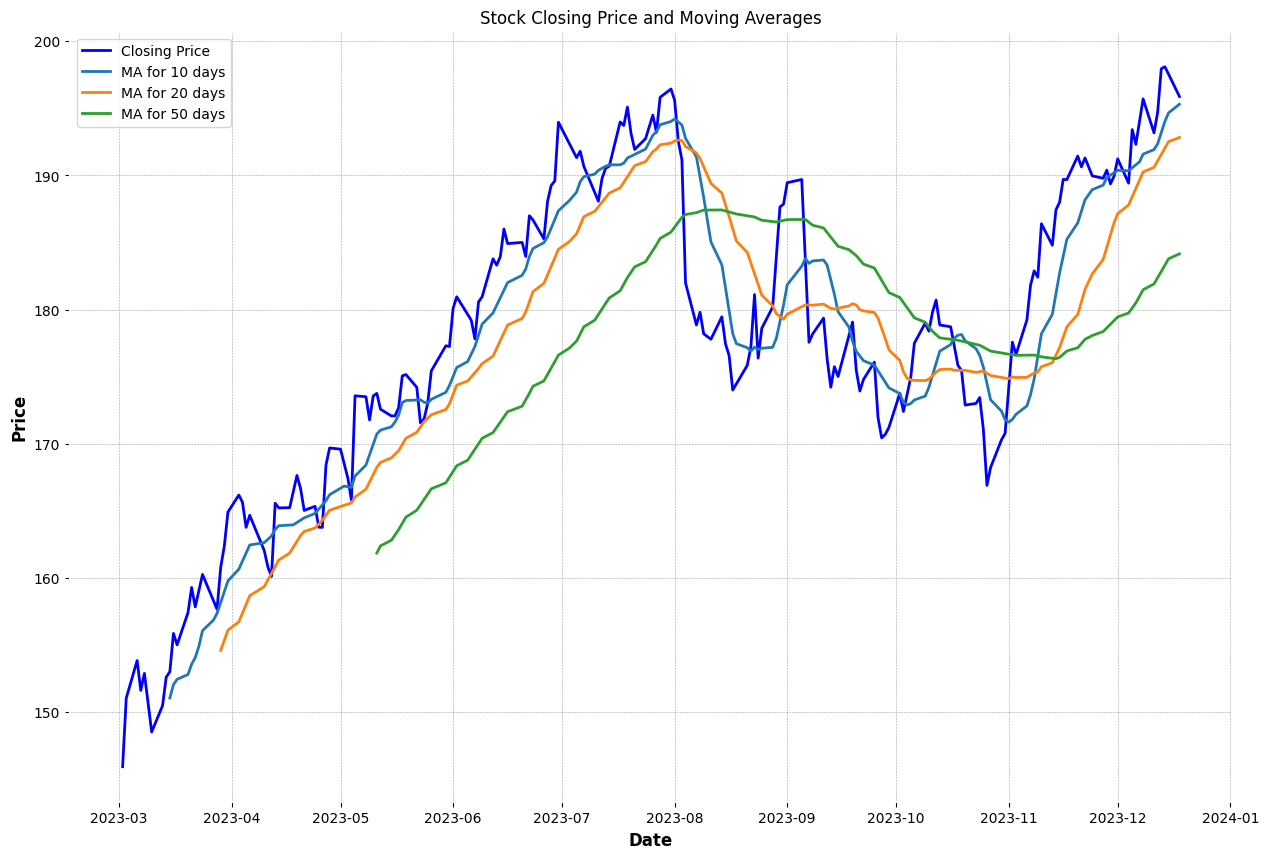

In [13]:
# Define moving average days
ma_day = [10, 20, 50]

for ma in ma_day: 
    column_name = f"MA for {ma} days"
    trainDf[column_name] = trainDf['Close'].rolling(ma).mean()

# Plotting
fig, ax = plt.subplots(figsize=(15, 10))

# Plot closing price and moving averages
ax.plot(trainDf.index, trainDf['Close'], label='Closing Price', color='blue')
for ma in ma_day:
    column_name = f"MA for {ma} days"
    ax.plot(trainDf.index, trainDf[column_name], label=column_name)

ax.set_title('Stock Closing Price and Moving Averages')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()

plt.show()

**And finally, dily returns.**

/tmp/ipykernel_34/1348437420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainDf['Daily Return'] = trainDf['Close'].pct_change()


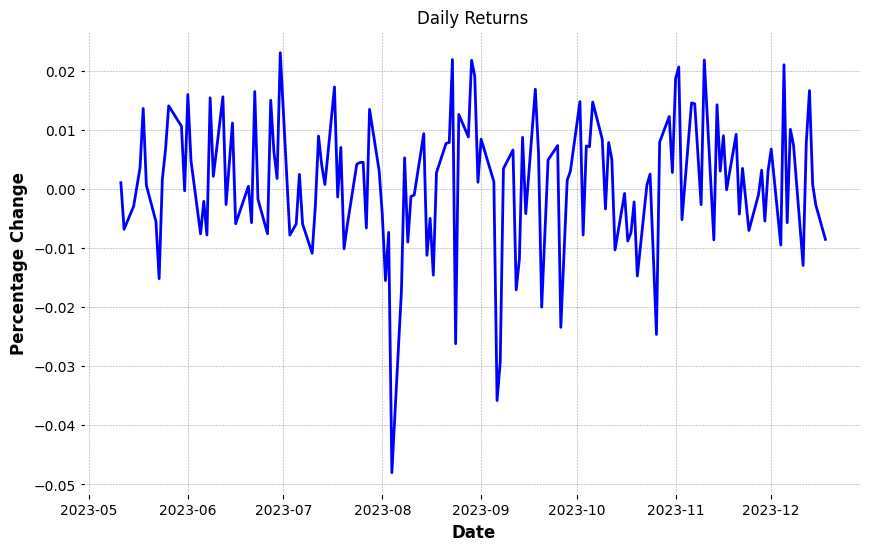

In [14]:
# Calculate daily returns
trainDf['Daily Return'] = trainDf['Close'].pct_change()

# Remove the first row since it will have a NaN value
trainDf = trainDf.dropna()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(trainDf.index, trainDf['Daily Return'], color='blue')
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.grid(True)
plt.show()

## First Method
We used GPT2 model for generating new tokens based on previous prices. In our first method we used A generative method using auto-regressive generators. This method makes use of previous data to generate new ones. we make each price a prompt, feed it to the model, and compare prices. training this model, we used the objective function to gather new data. 


In [15]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [16]:
encoded_prices = tokenizer.encode(" ".join([str(price) for price in trainCloses]), return_tensors="pt", max_length=1024, truncation=True)

model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.resize_token_embeddings(len(tokenizer))
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=1, factor=0.8
)

numEpoch = 5
totalLoss = 0

shifted_labels = torch.roll(encoded_prices, -1, dims=0)

shifted_labels[-1] = encoded_prices[-1]

for e in range(numEpoch):
    model.zero_grad()
    outputs = model(encoded_prices, labels=shifted_labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    totalLoss += loss.item()
    lr_scheduler.step(loss)

    print("epoch", e + 1,"total loss:", totalLoss / len(trainCloses))

epoch 1 total loss: 0.017086724243541754
epoch 2 total loss: 0.03192888510109174
epoch 3 total loss: 0.045436834344769465
epoch 4 total loss: 0.057877225450950094
epoch 5 total loss: 0.07003156973583864


In [17]:
generated = model.generate(encoded_prices, max_length=1024 + 1, temperature=1.0, num_return_sequences=1)
generated_prices = tokenizer.decode(generated[0], skip_special_tokens=True).split()

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


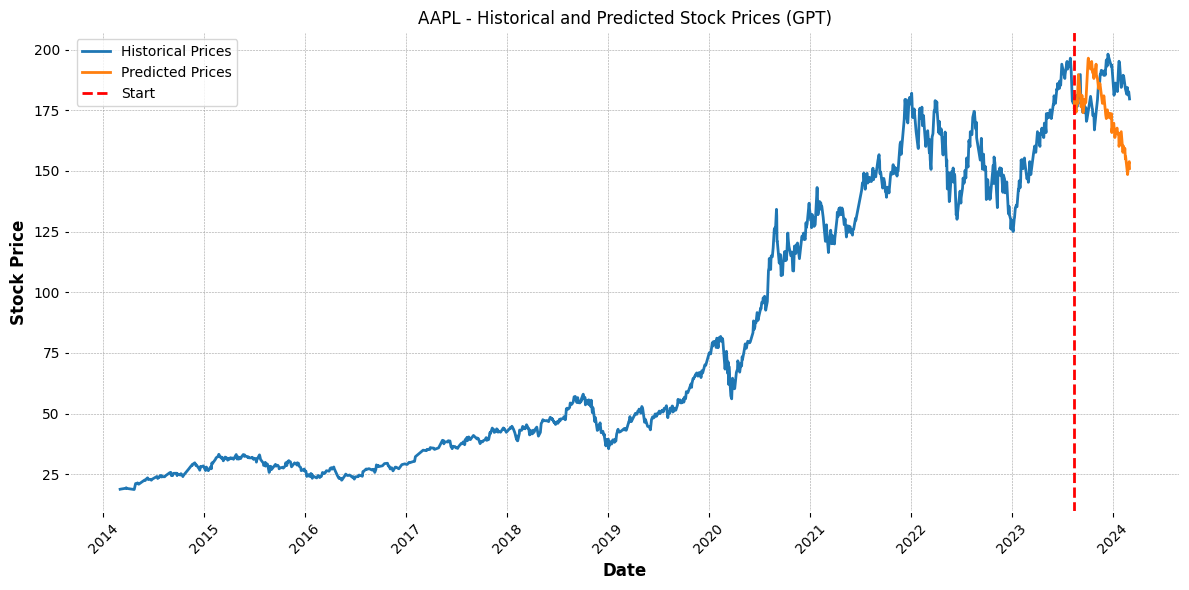

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Close"], label="Historical Prices", linewidth=2)
plt.plot(data.index[:-len(generated_prices):-1], [float(price) for price in generated_prices[1:]], label="Predicted Prices")
plt.axvline(data.index[:-len(generated_prices):-1][-1], color='r', linestyle='--', label="Start")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title(f"{ticker} - Historical and Predicted Stock Prices (GPT)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
(len(generated_prices))

140

## Evaluation
We use Rmse to judge the quality of the fit.

In [48]:
predicted = [float(price) for price in generated_prices[(len(generated_prices) - data.index.shape[0])-1:-1]]

actual = [float(price) for price in data["Close"].iloc[:-(len(generated_prices) - data.index.shape[0]):-1]]

mse = mean_squared_error(actual, predicted)

mse

360.6099804586902

## Next Method
In our second method, we use LSTM to generate through time, using Keras library to build the architecture.

In [49]:
from pandas_datareader import data as pdr
from datetime import datetime
df = yf.download("AAPL", period='10y') # Previous 10 years
df

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-03-03,18.693571,18.951786,18.671785,18.848572,16.602116,238781200
2014-03-04,18.964287,19.022858,18.848928,18.972857,16.711584,259140000
2014-03-05,18.961430,19.098213,18.897499,19.012857,16.746822,200062800
2014-03-06,19.028214,19.087143,18.860714,18.955357,16.696165,185488800
2014-03-07,18.967501,18.999287,18.787500,18.944286,16.686420,220729600
...,...,...,...,...,...,...
2024-02-26,182.240005,182.759995,180.649994,181.160004,181.160004,40867400
2024-02-27,181.100006,183.919998,179.559998,182.630005,182.630005,54318900
2024-02-28,182.509995,183.119995,180.130005,181.419998,181.419998,48953900


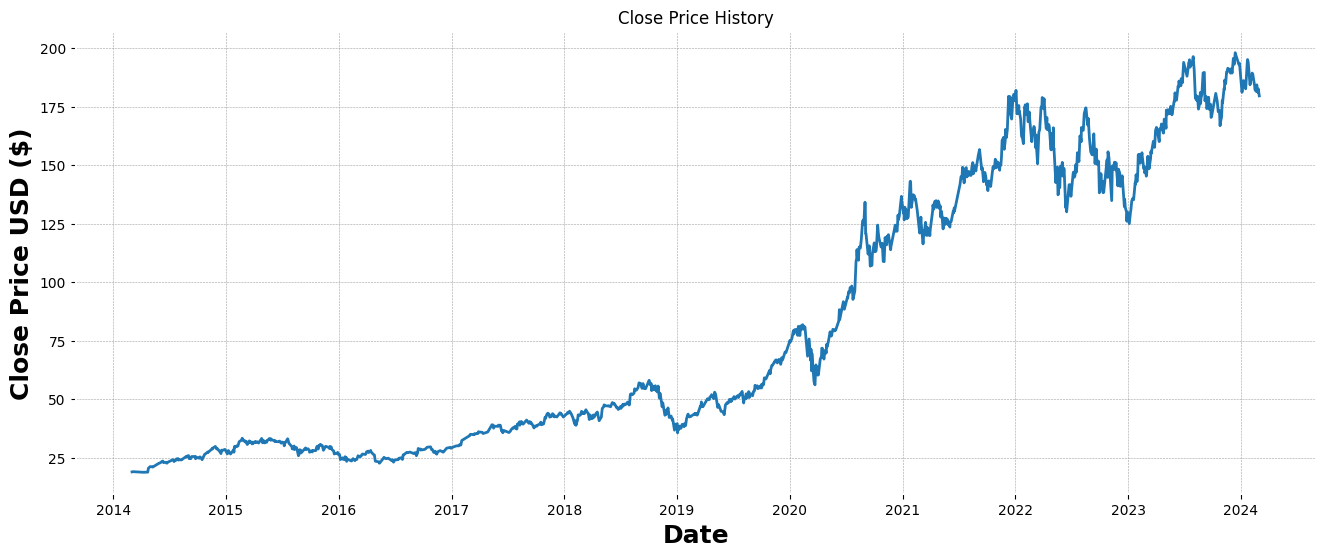

In [50]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [51]:
data = df.filter(['Close'])

dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

2393

In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00194865],
       [0.00264062],
       [0.00286333],
       ...,
       [0.90707717],
       [0.9033469 ],
       [0.89727827]])

In [53]:
train_data = scaled_data[0:int(training_data_len), :]
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)

x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

[array([0.00194865, 0.00264062, 0.00286333, 0.00254319, 0.00248155,
       0.002577  , 0.003605  , 0.0037084 , 0.00252331, 0.00133821,
       0.00174584, 0.00267243, 0.0026446 , 0.00213556, 0.00296473,
       0.00422142, 0.0053747 , 0.00433873, 0.00387742, 0.00375811,
       0.00373426, 0.00471056, 0.00488952, 0.00414188, 0.00275594,
       0.00109561, 0.00108966, 0.00245769, 0.00109761, 0.00032809,
       0.0007397 , 0.        , 0.00020879, 0.00138791, 0.00262671,
       0.00273209, 0.00135014, 0.00990432, 0.01073349, 0.01513784,
       0.01478787, 0.01434247, 0.01461887, 0.01483758, 0.01650388,
       0.01520147, 0.01478787, 0.0139249 , 0.01343774, 0.0148873 ,
       0.01507221, 0.01509409, 0.01408994, 0.01581788, 0.01722568,
       0.01724954, 0.01756769, 0.01775857, 0.01912263, 0.02140932])]
[0.021087190264195255]
[array([0.00194865, 0.00264062, 0.00286333, 0.00254319, 0.00248155,
       0.002577  , 0.003605  , 0.0037084 , 0.00252331, 0.00133821,
       0.00174584, 0.00267243, 0.00

In [54]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(x_train, y_train, batch_size=1, epochs=1)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2333/2333 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0023


In [57]:
test_data = scaled_data[training_data_len - 60: , :]

x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    

x_test = np.array(x_test)

x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.mean(((predictions - y_test) ** 2))
rmse

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


29.679846629776062

/tmp/ipykernel_34/3344400724.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


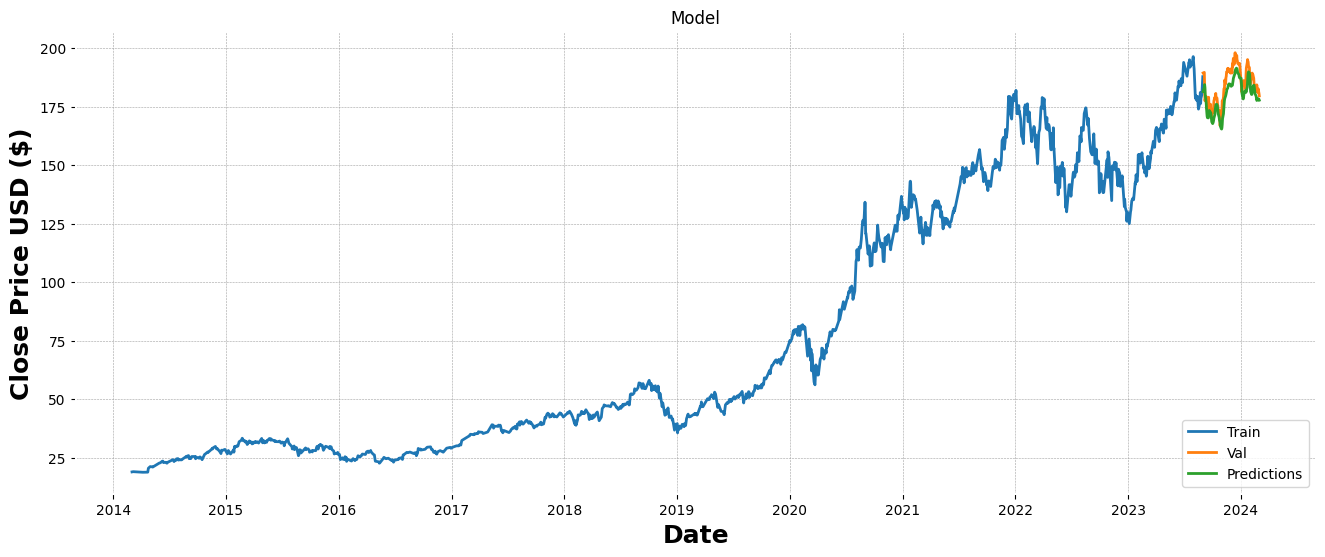

In [56]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

## Last Method
We use specific packages for time series forecasting like Prophet and Armia.

In [60]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.9 MB/s eta 0:00:0000:010:01


In [61]:
from sklearn.metrics import mean_absolute_error
import pmdarima as pm
import pandas as pd

# Assuming trainCloses and testCloses are pandas Series with datetime index

# Fit ARIMA model
model = pm.auto_arima(trainCloses, seasonal=True, m=12)

# Forecast
forecast, conf_int = model.predict(len(testCloses), return_conf_int=True)

# Calculate MAE
score_mae = mean_absolute_error(testCloses, forecast)
print("Mean Absolute Error (MAE):", score_mae)


Mean Absolute Error (MAE): 14.815375521850243


## Conclusion
We used different methods for stock markets prediction with each one having their own pros and cons.

## Refrences

- Special reference for the helpful information and plots - https://www.kaggle.com/iamleonie/intro-to-time-series-forecasting
- ARIMA - https://towardsdatascience.com/time-series-forecasting-arima-models-7f221e9eee06
- Auto-ARIMA - https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/
